In [1]:
!unzip data_case1.zip

Streaming output truncated to the last 5000 lines.
  inflating: data_case1/0062_v1_0.035_v2_0.001_tension_0.0025201.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375001.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375011.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375021.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375031.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375041.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375051.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375061.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375071.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375081.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375091.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375101.png  
  inflating: data_case1/0063_v1_0.035_v2_0.0015_tension_0.00375111.png  
  

# Importing Libraries

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Defining image specifications

In [3]:
num_frames = 21
img_height = 120  # Modify according to your image dimensions
img_width = 160   # Modify according to your image dimensions
num_channels = 3  # For RGB, use 1 for grayscale
input_shape = (num_frames, img_height, img_width, num_channels)

# Reading velocity labels

In [4]:
velocity_labels = pd.read_csv("/content/data_case1/simulation_data.csv")
velocity_labels.head(10)

,v1 (m/s),v2 (m/s),Surface Tension (N/m),v1/v2,Weber Number,Capillary Number
0,0.005,0.0005,0.00125,10.00000,0.048600,0.000496
1,0.005,0.0010,0.00250,5.00000,0.019200,0.000496
2,0.005,0.0015,0.00375,3.33333,0.009800,0.000496
3,0.005,0.0020,0.00500,2.50000,0.005400,0.000496
4,0.005,0.0025,0.00625,2.00000,0.003000,0.000496
5,0.005,0.0030,0.00750,1.66667,0.001600,0.000496
6,0.005,0.0035,0.00875,1.42857,0.000771,0.000496
7,0.005,0.0040,0.01000,1.25000,0.000300,0.000496
8,0.005,0.0045,0.01125,1.11111,0.000067,0.000496
9,0.005,0.0050,0.01250,1.00000,0.000000,0.000496


In [5]:
temp = np.array(velocity_labels)
size = temp.shape[0]
print(size)
temp2 = temp[:, 0:3] #Will be used while reading image data
print(temp2.shape)

300
(300, 3)


In [6]:
df = velocity_labels.iloc[:, -3]
df.shape

(300,)

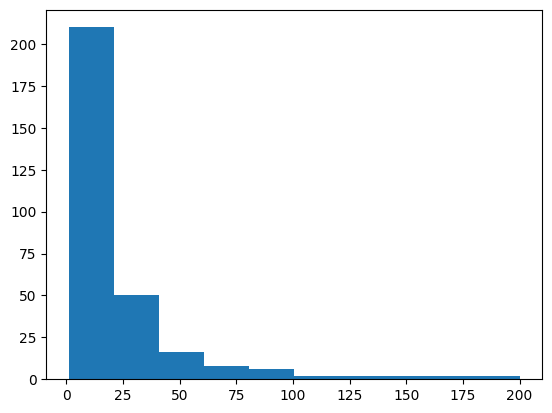

In [7]:
df = velocity_labels.iloc[:, -3]
plt.hist(df)
plt.show()

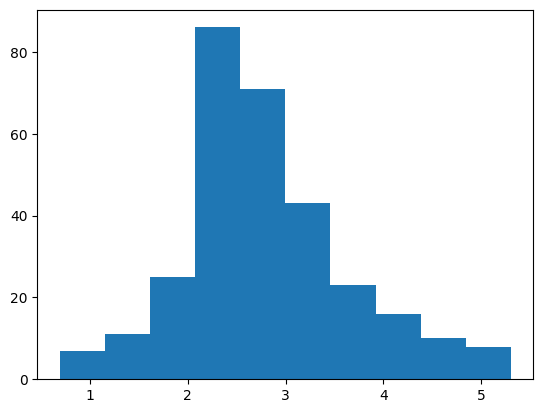

In [8]:
df_transformed= np.log(df + 1)
plt.hist(df_transformed)
plt.show()

In [9]:
df_transformed.shape

(300,)

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Reshape and normalize the data
normalized_df = scaler.fit_transform(df_transformed.values.reshape(-1, 1))

print(normalized_df.shape)

(300, 1)


In [17]:
y = normalized_df.flatten()
y.shape

(300,)

# Reading image data

In [19]:
image_folder = '/content/data_case1'

In [20]:
s = ['001','011','021','031','041','051','061','071','081','091','101','111','121','131','141','151','161','171','181','191','201']

In [21]:
def load_image_sequence(image_folder, start_idx, num_frames,s):
    images = []
    for i in range(num_frames):
        idx = start_idx + 1
        img_path = os.path.join(image_folder, f'{str(idx).zfill(4)}_v1_{temp2[start_idx][0]}_v2_{temp2[start_idx][1]}_tension_{temp2[start_idx][2]}{s[i]}.png')  # Modify if using a different format
        img = Image.open(img_path)
        #img = img.convert('L') #Grayscaling image
        img = img.resize((img_width,img_height))
        img_array = np.array(img)
        # if img_array.shape[-1] != num_channels:  # Convert to RGB if necessary
        #     img_array = np.repeat(img_array[..., np.newaxis], num_channels, -1)
        images.append(img_array)
    return np.stack(images, axis=0)

In [22]:
X = []

In [23]:
for start_idx in range(size):
    #start_idx = temp[idx][0] # Assuming 'start_image_idx' in CSV denotes the starting image for this sequence
    sequence = load_image_sequence(image_folder, start_idx, num_frames,s)
    X.append(sequence)

# Converting data to numpy arrays

In [24]:
X = np.array(X)
y = np.array(y)

In [25]:
X.shape #Shape: (num_samples, num_frames, img_height, img_width, num_channels)

(300, 21, 120, 160, 3)

In [26]:
y.shape

(300,)

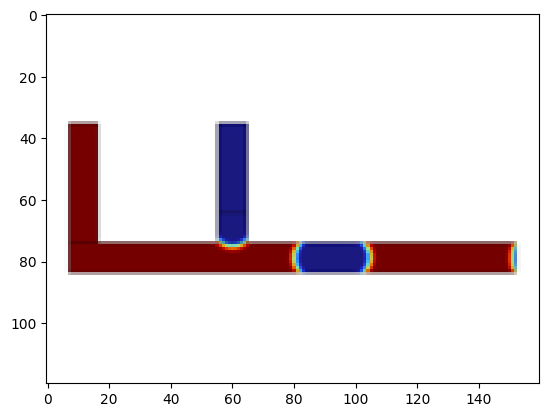

In [27]:
plt.imshow(X[4][17])

In [28]:
X = X.astype('float32') / 255.0 #Normalise image data

# Splitting data into train data and test data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Building a simple 3D CNN model

In [30]:
# Initialising the Sequential model
model = Sequential()

# 3D Convolutional Layer 1
model.add(Conv3D(filters=16, kernel_size=(3, 3, 3), activation='relu', input_shape=(num_frames, img_height, img_width, num_channels)))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))

# 3D Convolutional Layer 2
model.add(Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))

# Flatten the output
model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer (single value - velocity)
model.add(Dense(1, activation='linear'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                      │ (None, 19, 118, 158, 16)    │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 19, 59, 79, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 17, 57, 77, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 17, 28, 38, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 578816)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      37,044,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,061,569 (141.38 MB)

 Trainable params: 37,061,569 (141.38 MB)

 Non-trainable params: 0 (0.00 B)

# Fitting model on train data

In [31]:
history = model.fit(X_train, y_train, epochs=30, batch_size=2)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 44.2834 - mae: 2.3228
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0118 - mae: 0.0804
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0042 - mae: 0.0504
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0029 - mae: 0.0388
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0050 - mae: 0.0526
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0039 - mae: 0.0503
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0018 - mae: 0.0338
Epoch 8/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0020 - mae: 0.0341
Epoch 9/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0011 - mae: 0.0245
Epoch 10/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0034 - mae: 0.0483
Epoch 11/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0014 - mae: 0.0288
Epoch 12/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0067 - mae: 0.0607
Epoch 13/30

# Calculating R2 score of train data

In [32]:
from sklearn.metrics import r2_score
# Make predictions on the test set
predictions_train = model.predict(X_train)

# Calculate the R^2 score
r2 = r2_score(y_train, predictions_train)
print(f'R^2 Score: {r2}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step
R^2 Score: 0.9794409814819383


# Calculating r2 score of test data

In [33]:
from sklearn.metrics import r2_score
# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate the R^2 score
r2 = r2_score(y_test, predictions)
print(f'R^2 Score: {r2}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
R^2 Score: 0.9684441796366


# Making predictions using model

In [39]:
predict_values = model.predict(X)
predict_values_actual = scaler.inverse_transform(predict_values)
predict_values_actual = np.exp(predict_values_actual)-1
predict_values_actual = predict_values_actual.squeeze()
results_df = pd.DataFrame({
    'Actual v1/v2': df,
    'Predicted v1/v2': predict_values_actual
})
results_df.to_csv('predictions_output.csv',index = False)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step


In [36]:
predict_values.shape

(300, 1)

In [40]:
results_df.head(10)

,Actual v1/v2,Predicted v1/v2
0,10.00000,17.630903
1,5.00000,6.204214
2,3.33333,3.593167
3,2.50000,2.606673
4,2.00000,2.336581
5,1.66667,1.842075
6,1.42857,1.827879
7,1.25000,1.625067
8,1.11111,1.498273
9,1.00000,1.468825


# Comparing actual and predicted values

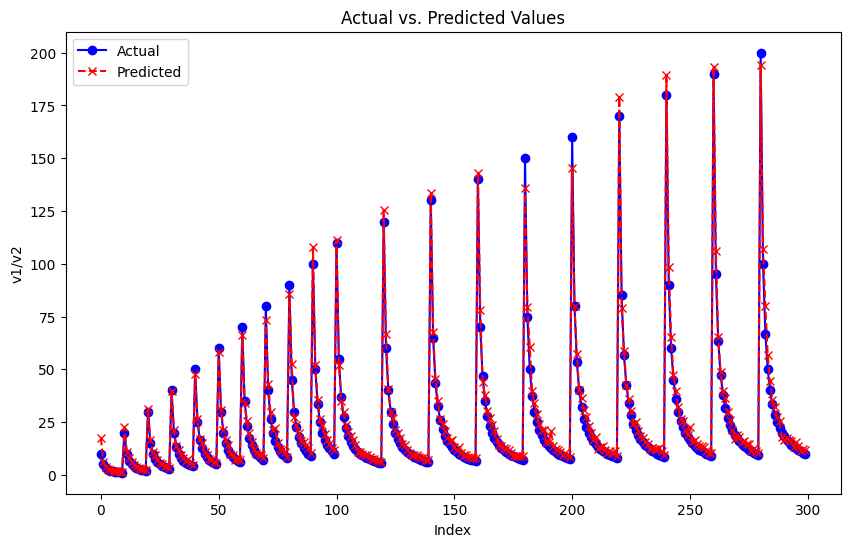

In [41]:
# Plot the actual and predicted values
plt.figure(figsize=(10, 6))
plt.plot(results_df['Actual v1/v2'], label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(results_df['Predicted v1/v2'], label='Predicted', color='red', linestyle='--', marker='x')

# Add labels and title
plt.xlabel('Index')
plt.ylabel('v1/v2')
plt.title('Actual vs. Predicted Values')

# Add a legend
plt.legend()

# Show the plot
plt.show()

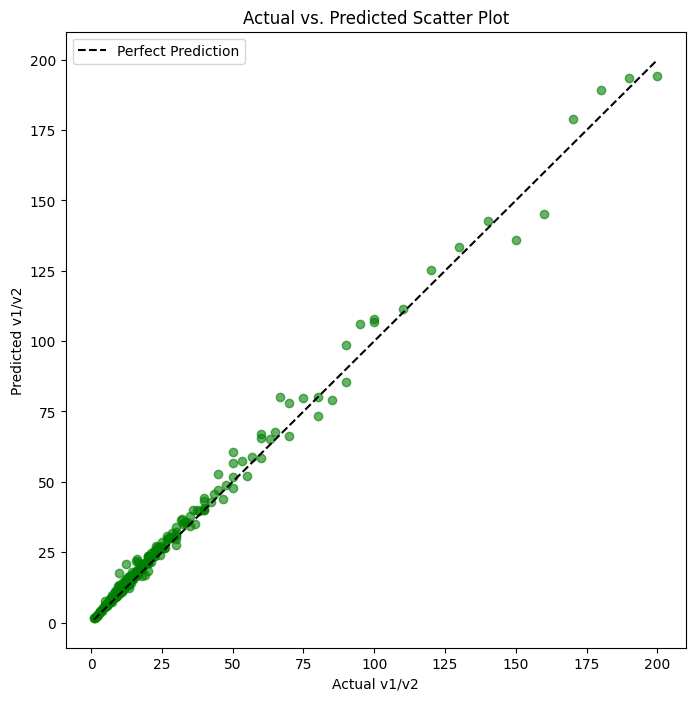

In [46]:
plt.figure(figsize=(8, 8))
plt.scatter(results_df['Actual v1/v2'], results_df['Predicted v1/v2'], color='green', alpha=0.6)

# Plot a line for perfect prediction (Actual = Predicted)
plt.plot([min(results_df['Actual v1/v2']), max(results_df['Actual v1/v2'])],
         [min(results_df['Actual v1/v2']), max(results_df['Actual v1/v2'])],
         color='black', linestyle='--', label='Perfect Prediction')

# Add labels and title
plt.xlabel('Actual v1/v2')
plt.ylabel('Predicted v1/v2')
plt.title('Actual vs. Predicted Scatter Plot')

# Show the plot
plt.legend()
plt.show()

# Saving the model

In [44]:
model.save('3d_cnn_velocity_model_case1.keras')